# Loading The Data

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#ml libs
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_recall_curve, f1_score
import warnings
warnings.filterwarnings('ignore')

# Basic Exploration

In [58]:
df = pd.read_csv('customer_churn_dataset.csv',encoding='utf-8')

print(f'Dataset shape: {df.shape}\n')
print(f'First few rows of data: \n{df.head()}\n')

Dataset shape: (100000, 9)

First few rows of data: 
   CustomerID        Name  Age  Gender     Location  \
0           1  Customer_1   63    Male  Los Angeles   
1           2  Customer_2   62  Female     New York   
2           3  Customer_3   24  Female  Los Angeles   
3           4  Customer_4   36  Female        Miami   
4           5  Customer_5   46  Female        Miami   

   Subscription_Length_Months  Monthly_Bill  Total_Usage_GB  Churn  
0                          17         73.36             236      0  
1                           1         48.76             172      0  
2                           5         85.47             460      0  
3                           3         97.94             297      1  
4                          19         58.14             266      0  



# Exploratory Data Analysis

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CustomerID                  100000 non-null  int64  
 1   Name                        100000 non-null  object 
 2   Age                         100000 non-null  int64  
 3   Gender                      100000 non-null  object 
 4   Location                    100000 non-null  object 
 5   Subscription_Length_Months  100000 non-null  int64  
 6   Monthly_Bill                100000 non-null  float64
 7   Total_Usage_GB              100000 non-null  int64  
 8   Churn                       100000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 6.9+ MB


In [60]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [61]:
print(f'Overall summary of the dataset:\n{df.describe()}\n')

Overall summary of the dataset:
          CustomerID            Age  Subscription_Length_Months  \
count  100000.000000  100000.000000               100000.000000   
mean    50000.500000      44.027020                   12.490100   
std     28867.657797      15.280283                    6.926461   
min         1.000000      18.000000                    1.000000   
25%     25000.750000      31.000000                    6.000000   
50%     50000.500000      44.000000                   12.000000   
75%     75000.250000      57.000000                   19.000000   
max    100000.000000      70.000000                   24.000000   

        Monthly_Bill  Total_Usage_GB          Churn  
count  100000.000000   100000.000000  100000.000000  
mean       65.053197      274.393650       0.497790  
std        20.230696      130.463063       0.499998  
min        30.000000       50.000000       0.000000  
25%        47.540000      161.000000       0.000000  
50%        65.010000      274.000000    

## Interpretation of Data

- Mostly the users are above 40 years old, while the overall spread of age ranges from 18 to 70 years old.
- Users stay subscribed for more than a year, with 75% of the users retaining their connection for upto 19 months.
- No user has a monthly bill of less than $30, while most of the users pay $65/month to their provider.
- Each subscriber uses on average 274GB of data in a month.
- The dataset is balanced in terms of churn, with almost 50% spread in churn and no churn users.

In [62]:
df.describe(include=['object'])

,Name,Gender,Location
count,100000,100000,100000
unique,100000,2,5
top,Customer_99961,Female,Houston
freq,1,50216,20157


In [63]:
#count of users by gender
df['Gender'].value_counts()

Gender
Female    50216
Male      49784
Name: count, dtype: int64

In [64]:
#count of subscribers by location
df['Location'].value_counts()

Location
Houston        20157
Los Angeles    20041
Miami          20031
Chicago        19958
New York       19813
Name: count, dtype: int64

## Interpretation of categorical features
- Female subscribers are slightly more than male in number
- Houston has the most subscribers, followed by Los Angeles and a close third by Miami

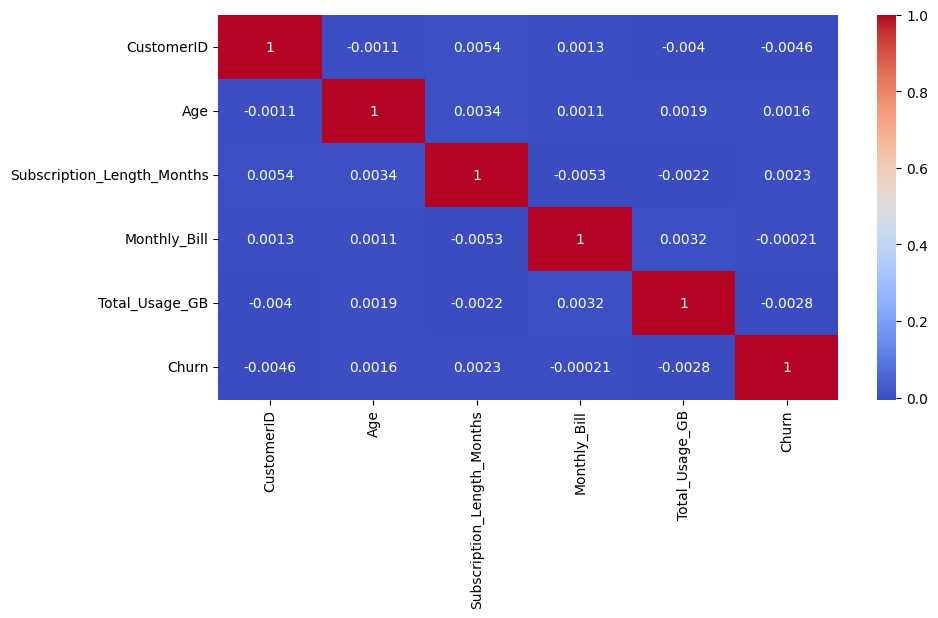

In [65]:
#heatmap for correlation of features

cm = df.corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(cm, cmap='coolwarm', annot=True)

plt.show()

### We have customer ID and name of users, but it is irrelevant in predicting churn, so we can drop both these columns

In [66]:
df.drop(['CustomerID', 'Name'], axis=1, inplace=True)

In [67]:
df.columns

Index(['Age', 'Gender', 'Location', 'Subscription_Length_Months',
       'Monthly_Bill', 'Total_Usage_GB', 'Churn'],
      dtype='object')

In [68]:
df.shape

(100000, 7)

2 columns dropped, thus 7 columns remain

In [69]:
df.dtypes

Age                             int64
Gender                         object
Location                       object
Subscription_Length_Months      int64
Monthly_Bill                  float64
Total_Usage_GB                  int64
Churn                           int64
dtype: object

Everything is in the right format / data type

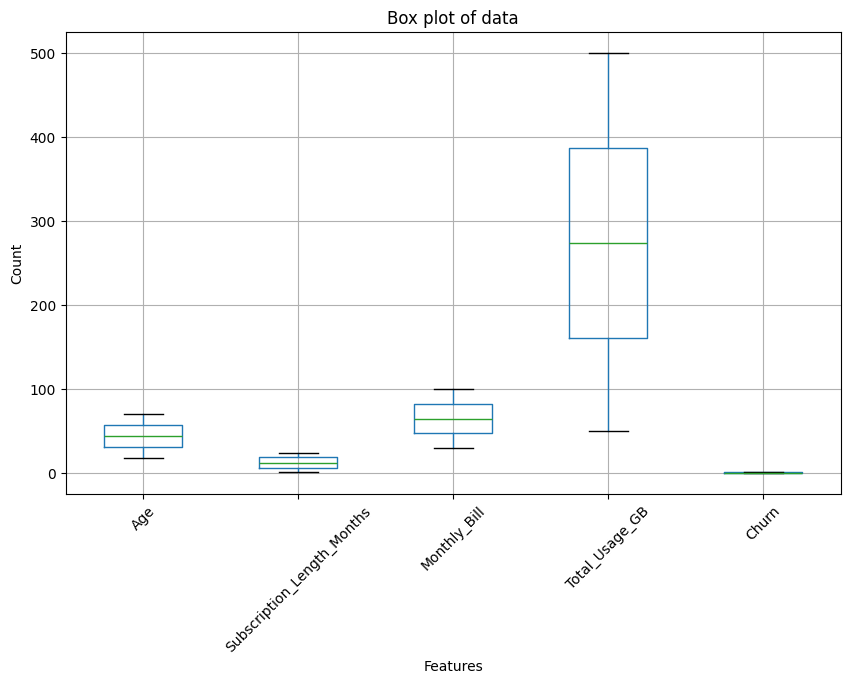

In [70]:
fig, ax = plt.subplots(figsize=(10,6))
df.boxplot(ax=ax)

plt.title('Box plot of data')
plt.xlabel('Features')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The data is overall balanced, no specific outliers

In [71]:
#creating copy of clean dataset
df_clean = df.copy()

## Feature Encoding for Categorical Features

Encoding gender and location into numerical representation

In [72]:
le_gender = LabelEncoder()
le_location = LabelEncoder()

df['gender_encoded'] = le_gender.fit_transform(df['Gender'])
df['location_encoded'] = le_location.fit_transform(df['Location'])

display(df['gender_encoded'].head())
display(df['location_encoded'].head())

0    1
1    0
2    0
3    0
4    0
Name: gender_encoded, dtype: int64

0    2
1    4
2    2
3    3
4    3
Name: location_encoded, dtype: int64

In [73]:
df.drop(['Gender', 'Location'],axis=1, inplace=True)

In [56]:
df.head()

,Age,Subscription_Length_Months,Monthly_Bill,Total_Usage_GB,Churn,gender_encoded,location_encoded
0,63,17,73.36,236,0,1,2
1,62,1,48.76,172,0,0,4
2,24,5,85.47,460,0,0,2
3,36,3,97.94,297,1,0,3
4,46,19,58.14,266,0,0,3


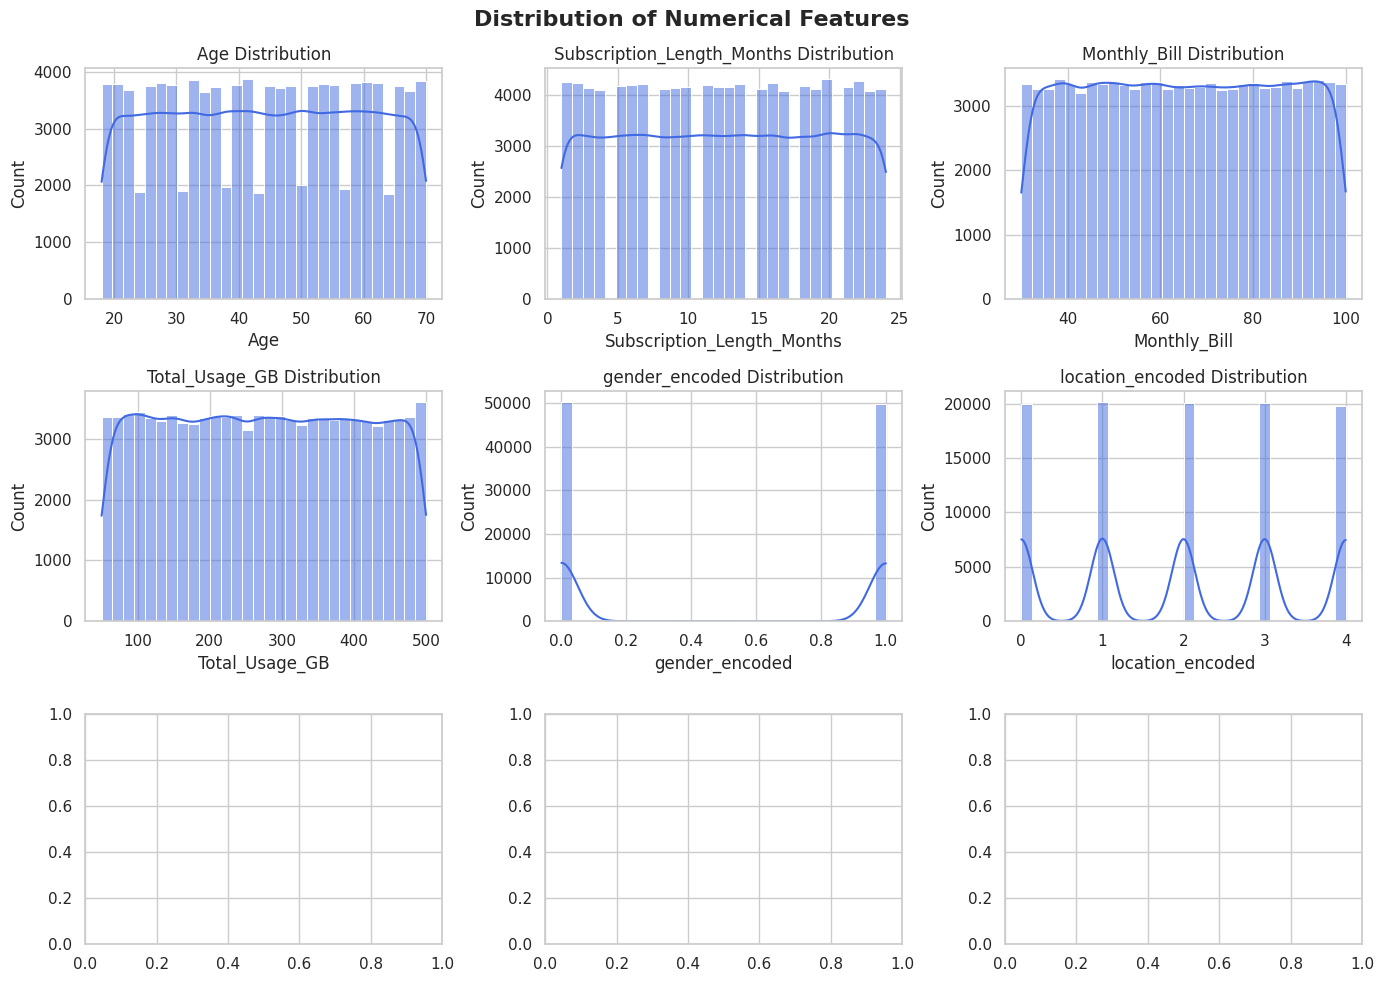

In [ ]:
# Set the visual style
sns.set_theme(style="whitegrid")

num_cols = ['Age', 'Subscription_Length_Months', 'Monthly_Bill', 'Total_Usage_GB', 'gender_encoded', 'location_encoded']

# Create a 3x3 grid of subplots for numbers
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

for i, col in enumerate(num_cols):
    row_idx = i // 3
    col_idx = i % 3
    # KDE = True adds a smooth curve line over the histogram!
    sns.histplot(data=df, x=col, kde=True, ax=axes[row_idx, col_idx], color='royalblue', bins=30)
    axes[row_idx, col_idx].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

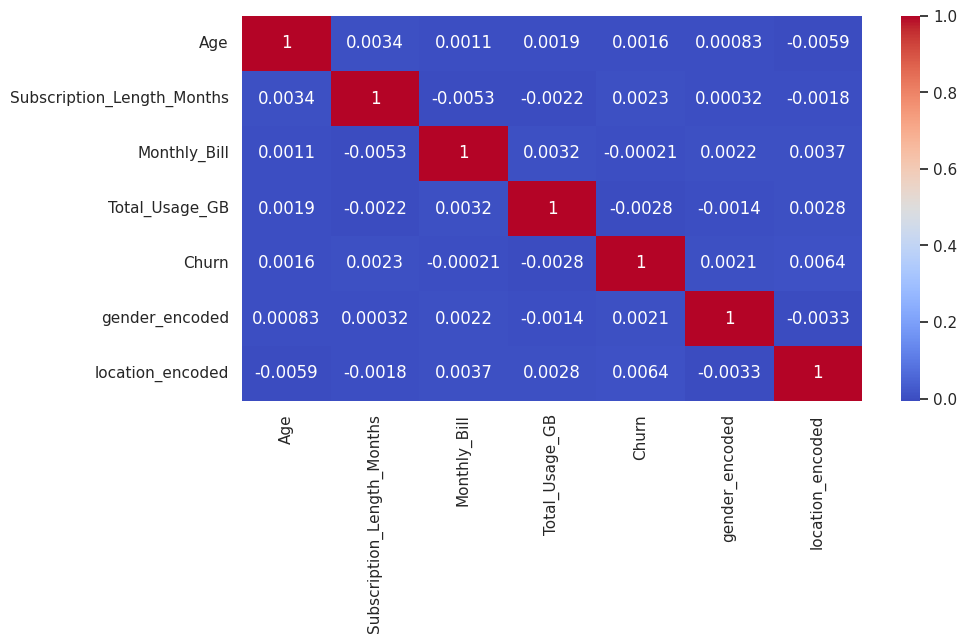

In [80]:
#heatmap for correlation of features

cm = df.corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(cm, cmap='coolwarm', annot=True)

plt.show()

# Feature Engineering

In [ ]:
df['usage_per_month'] = df['Total_Usage_GB'] / df['Subscription_Length_Months']
df['customer_lifetime_value'] = df['Subscription_Length_Months'] * df['Monthly_Bill']

df['high_usage'] = (df['Total_Usage_GB'] > df['Total_Usage_GB'].median()).astype(int)
df['long_tenure'] = (df['Subscription_Length_Months'] > 12).astype(int)
df['premium_user'] = (df['Monthly_Bill'] > df['Monthly_Bill'].quantile(0.75)).astype(int)



In [85]:
df['high_bill_low_usage'] = ((df['Monthly_Bill'] > df['Monthly_Bill'].median()) & 
                              (df['Total_Usage_GB'] < df['Total_Usage_GB'].median())).astype(int)
location_churn_rate = df.groupby('location_encoded')['Churn'].transform('mean')
df['location_churn_risk'] = location_churn_rate

gender_churn_rate = df.groupby('gender_encoded')['Churn'].transform('mean')
df['gender_churn_risk'] = gender_churn_rate

In [86]:
df['usage_per_month'] = df['Total_Usage_GB'] / df['Subscription_Length_Months']
df['bill_per_gb'] = df['Monthly_Bill'] / (df['Total_Usage_GB'] + 1)  # Cost efficiency
df['usage_intensity'] = df['Total_Usage_GB'] / (df['Age'] + 1)  # Age-normalized usage

# ---- Value Features ----
df['customer_lifetime_value'] = df['Subscription_Length_Months'] * df['Monthly_Bill']
df['revenue_per_gb'] = df['Monthly_Bill'] / (df['Total_Usage_GB'] + 1)

# ---- Binary Flags (these are powerful for trees) ----
df['high_usage'] = (df['Total_Usage_GB'] > df['Total_Usage_GB'].median()).astype(int)
df['long_tenure'] = (df['Subscription_Length_Months'] > df['Subscription_Length_Months'].median()).astype(int)
df['premium_user'] = (df['Monthly_Bill'] > df['Monthly_Bill'].quantile(0.75)).astype(int)
df['low_usage'] = (df['Total_Usage_GB'] < df['Total_Usage_GB'].quantile(0.25)).astype(int)

# ---- Risk Indicators ----
df['high_bill_low_usage'] = ((df['Monthly_Bill'] > df['Monthly_Bill'].median()) & 
                              (df['Total_Usage_GB'] < df['Total_Usage_GB'].median())).astype(int)

# ---- Group-Based Features (powerful but careful of data leakage) ----
# These should ideally be calculated using only training data
location_churn_rate = df.groupby('location_encoded')['Churn'].transform('mean')
df['location_churn_risk'] = location_churn_rate

gender_churn_rate = df.groupby('gender_encoded')['Churn'].transform('mean')
df['gender_churn_risk'] = gender_churn_rate

In [87]:
# Usage segments (captures non-linear patterns)
df['usage_segment'] = pd.qcut(df['Total_Usage_GB'], q=4, 
                               labels=['Low', 'Medium', 'High', 'Very_High'])
df['usage_segment'] = LabelEncoder().fit_transform(df['usage_segment'])

# Tenure segments
df['tenure_segment'] = pd.cut(df['Subscription_Length_Months'], 
                               bins=[0, 3, 6, 12, 18, 24],
                               labels=['New', 'Settling', 'Established', 'Loyal', 'Veteran'])
df['tenure_segment'] = LabelEncoder().fit_transform(df['tenure_segment'])

# Age-based segments  
df['age_segment'] = pd.cut(df['Age'], 
                            bins=[0, 25, 35, 50, 65, 100],
                            labels=['GenZ', 'Millennial', 'GenX', 'Boomer', 'Senior'])
df['age_segment'] = LabelEncoder().fit_transform(df['age_segment'])

# Bill to usage mismatch (strong churn indicator)
df['bill_usage_efficiency'] = df['Total_Usage_GB'] / df['Monthly_Bill']  # Higher = better value
df['is_low_value'] = (df['bill_usage_efficiency'] < df['bill_usage_efficiency'].median()).astype(int)

# Location-based usage patterns
location_avg_usage = df.groupby('location_encoded')['Total_Usage_GB'].transform('mean')
df['location_usage_vs_avg'] = df['Total_Usage_GB'] / (location_avg_usage + 1)

In [88]:
print("Feature engineering complete!")
print(f"Total features: {df.shape[1]}")
print(f"Target variable: Churn")
print(f"\nNew features added:")
new_features = [col for col in df.columns if col not in 
                ['Age', 'Gender', 'Location', 'Subscription_Length_Months',
                 'Monthly_Bill', 'Total_Usage_GB', 'Churn', 
                 'gender_encoded', 'location_encoded']]
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

Feature engineering complete!
Total features: 26
Target variable: Churn

New features added:
  1. usage_per_month
  2. usage_intensity
  3. monthly_consumption_rate
  4. customer_lifetime_value
  5. high_usage
  6. long_tenure
  7. premium_user
  8. high_bill_low_usage
  9. location_churn_risk
  10. gender_churn_risk
  11. bill_per_gb
  12. revenue_per_gb
  13. low_usage
  14. usage_segment
  15. tenure_segment
  16. age_segment
  17. bill_usage_efficiency
  18. is_low_value
  19. location_usage_vs_avg


In [89]:
from sklearn.model_selection import train_test_split


In [90]:
df.head()

,Age,Subscription_Length_Months,Monthly_Bill,Total_Usage_GB,Churn,gender_encoded,location_encoded,usage_per_month,usage_intensity,monthly_consumption_rate,...,gender_churn_risk,bill_per_gb,revenue_per_gb,low_usage,usage_segment,tenure_segment,age_segment,bill_usage_efficiency,is_low_value,location_usage_vs_avg
0,63,17,73.36,236,0,1,2,13.882353,3.687500,13.882353,...,0.498855,0.309536,0.309536,0,2,1,0,3.217012,1,0.858223
1,62,1,48.76,172,0,0,4,172.000000,2.730159,172.000000,...,0.496734,0.281850,0.281850,0,2,2,0,3.527482,1,0.622877
2,24,5,85.47,460,0,0,2,92.000000,18.400000,92.000000,...,0.496734,0.185401,0.185401,0,3,3,2,5.382005,0,1.672808
3,36,3,97.94,297,1,0,3,99.000000,8.027027,99.000000,...,0.496734,0.328658,0.328658,0,0,2,1,3.032469,1,1.077110
4,46,19,58.14,266,0,0,3,14.000000,5.659574,14.000000,...,0.496734,0.217753,0.217753,0,2,4,1,4.575163,0,0.964685


In [92]:
X = df.drop('Churn', axis=1)
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y) #stratify ensures 80:20 split everytime

# Location churn risk (using only training data)
train_location_churn = y_train.groupby(X_train['location_encoded']).mean()
X_train['location_churn_risk'] = X_train['location_encoded'].map(train_location_churn)
X_test['location_churn_risk'] = X_test['location_encoded'].map(train_location_churn)

# Gender churn risk (using only training data)
train_gender_churn = y_train.groupby(X_train['gender_encoded']).mean()
X_train['gender_churn_risk'] = X_train['gender_encoded'].map(train_gender_churn)
X_test['gender_churn_risk'] = X_test['gender_encoded'].map(train_gender_churn)

# Location avg usage (using only training data)
train_location_usage = X_train.groupby('location_encoded')['Total_Usage_GB'].mean()
X_train['location_usage_vs_avg'] = X_train['Total_Usage_GB'] / X_train['location_encoded'].map(train_location_usage)
X_test['location_usage_vs_avg'] = X_test['Total_Usage_GB'] / X_test['location_encoded'].map(train_location_usage)


In [105]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,   #to prevent overfitting
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [106]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"\nNumber of trees: {rf_model.n_estimators}")
print(f"Max depth: {rf_model.max_depth}")


Number of trees: 200
Max depth: 15


In [ ]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"  Accuracy:  {accuracy:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"  F1 Score:  {f1:.4f}")


  Accuracy:  0.5015
  ROC-AUC:   0.5013
  F1 Score:  0.4528


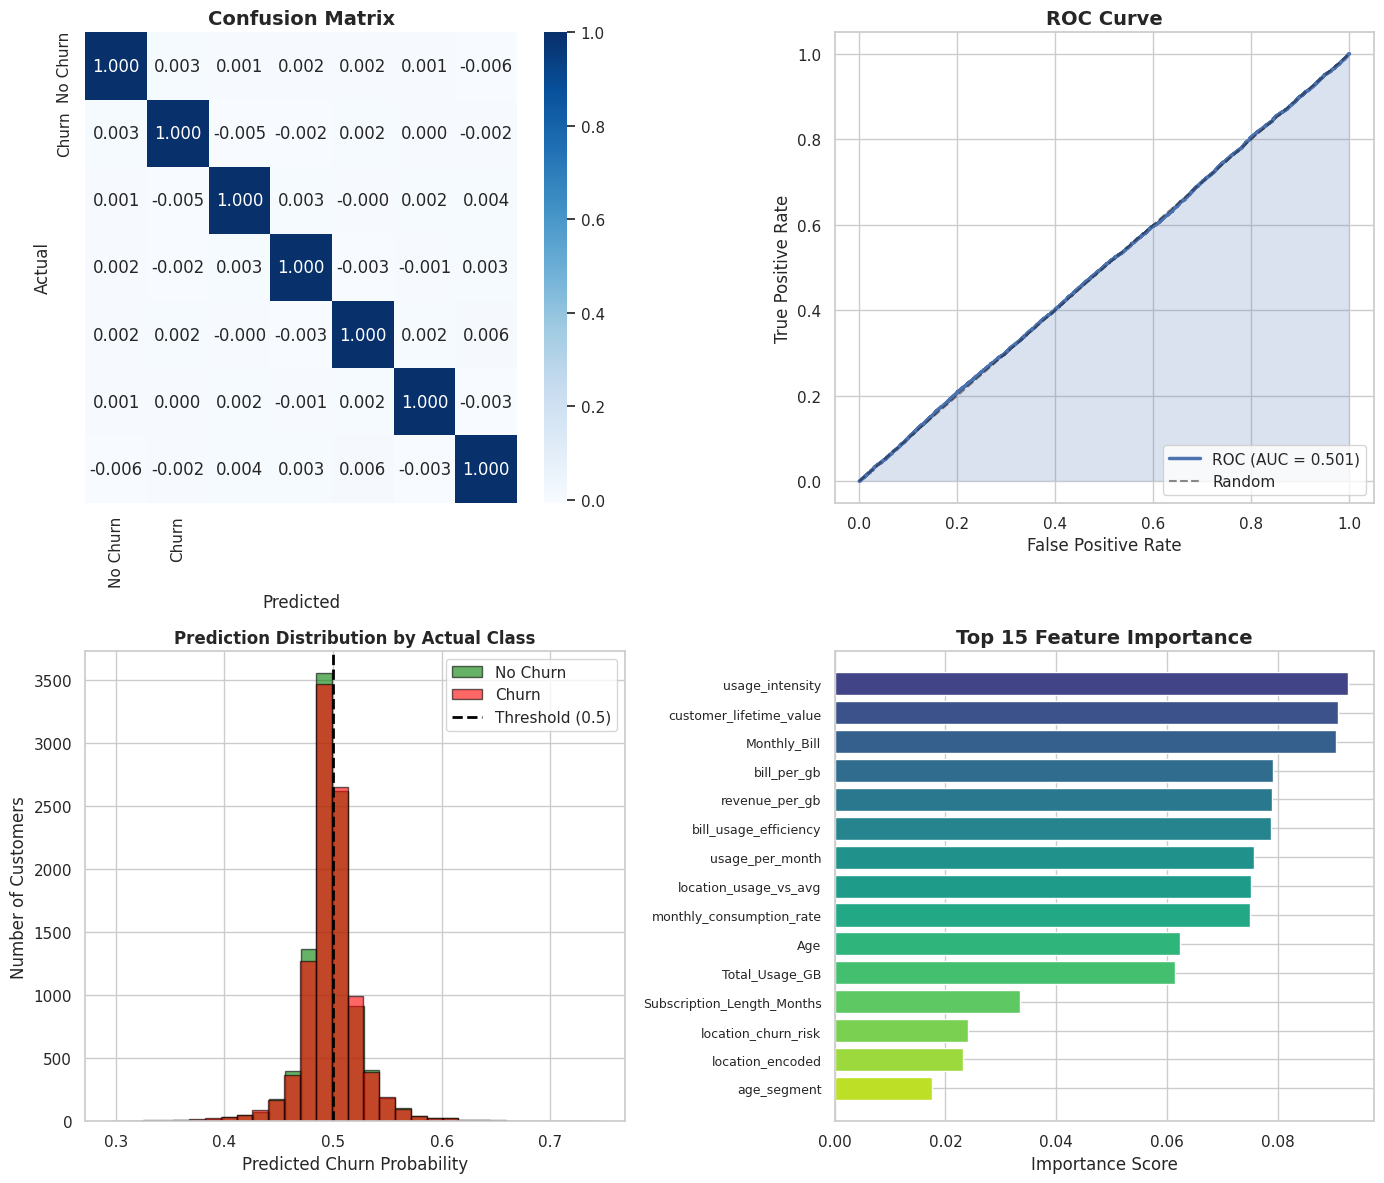


TOP 10 MOST IMPORTANT FEATURES
   1. usage_intensity                0.0927
   2. customer_lifetime_value        0.0909
   3. Monthly_Bill                   0.0905
   4. bill_per_gb                    0.0791
   5. revenue_per_gb                 0.0789
   6. bill_usage_efficiency          0.0787
   7. usage_per_month                0.0757
   8. location_usage_vs_avg          0.0752
   9. monthly_consumption_rate       0.0750
  10. Age                            0.0623


In [112]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, linewidth=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0, 1].fill_between(fpr, tpr, alpha=0.2)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower right')

# 3. Prediction Distribution
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label='No Churn', color='green', edgecolor='black')
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Churn', color='red', edgecolor='black')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1, 0].set_xlabel('Predicted Churn Probability')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].set_title('Prediction Distribution by Actual Class', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# 4. Feature Importance (Top 15)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

top_15 = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 15))
axes[1, 1].barh(range(15), top_15['importance'].values, color=colors)
axes[1, 1].set_yticks(range(15))
axes[1, 1].set_yticklabels(top_15['feature'].values, fontsize=9)
axes[1, 1].set_xlabel('Importance Score')
axes[1, 1].set_title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Print top 10 features
print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)
for i, (feature, importance) in enumerate(zip(top_15['feature'].head(10), 
                                                top_15['importance'].head(10)), 1):
    print(f"  {i:2}. {feature:<30} {importance:.4f}")

In [113]:
# ============================================
# STEP 8: BUSINESS INSIGHTS
# ============================================

# Create results dataframe
results = X_test.copy()
results['actual_churn'] = y_test.values
results['churn_probability'] = y_pred_proba
results['predicted_churn'] = y_pred

# Risk segments
results['risk_segment'] = pd.cut(
    results['churn_probability'], 
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

print("="*60)
print("CUSTOMER RISK SEGMENTS")
print("="*60)
risk_dist = results['risk_segment'].value_counts()
for risk in ['Critical Risk', 'High Risk', 'Medium Risk', 'Low Risk']:
    count = risk_dist.get(risk, 0)
    pct = count / len(results) * 100
    print(f"  {risk:<15}: {count:>6,} customers ({pct:5.1f}%)")

# Profile high-risk customers
high_risk = results[results['churn_probability'] > 0.5]
low_risk = results[results['churn_probability'] <= 0.3]

print("\n" + "="*60)
print("HIGH-RISK CUSTOMER PROFILE (>50% churn probability)")
print("="*60)

profile_cols = ['Age', 'Subscription_Length_Months', 'Monthly_Bill', 
                'Total_Usage_GB', 'usage_per_month', 'bill_per_gb',
                'customer_lifetime_value', 'usage_intensity']

for col in profile_cols:
    if col in results.columns:
        high_val = high_risk[col].mean()
        low_val = low_risk[col].mean()
        diff = high_val - low_val
        print(f"  {col:<30}: High={high_val:>8.1f}  Low={low_val:>8.1f}  Diff={diff:>8.1f}")

print("\n" + "="*60)
print("KEY BUSINESS RECOMMENDATIONS")
print("="*60)

# Analyze top features for insights
top_features = feature_importance.head(10)['feature'].tolist()

if 'bill_per_gb' in top_features:
    print("\n💡 PRICING OPTIMIZATION:")
    print("   High cost per GB is a strong churn predictor")
    print("   → Review pricing for high bill-per-GB customers")
    print("   → Offer plan optimization or unlimited data options")

if 'Subscription_Length_Months' in top_features:
    print("\n💡 CUSTOMER LIFECYCLE:")
    print("   Tenure significantly impacts churn risk")
    print("   → Implement onboarding program for months 1-3")
    print("   → Loyalty rewards for customers beyond 12 months")

if 'Total_Usage_GB' in top_features:
    print("\n💡 USAGE ENGAGEMENT:")
    print("   Usage patterns strongly predict churn")
    print("   → Create engagement campaigns for low-usage customers")
    print("   → Monitor for sudden usage drops as early warning")

if 'Monthly_Bill' in top_features:
    print("\n💡 BILL MANAGEMENT:")
    print("   Monthly bill amount impacts churn decisions")
    print("   → Offer flexible payment options")
    print("   → Proactive discount offers for price-sensitive segments")

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Algorithm: Random Forest")
print(f"Number of features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")

CUSTOMER RISK SEGMENTS
  Critical Risk  :      6 customers (  0.0%)
  High Risk      :  8,258 customers ( 41.3%)
  Medium Risk    : 11,735 customers ( 58.7%)
  Low Risk       :      1 customers (  0.0%)

HIGH-RISK CUSTOMER PROFILE (>50% churn probability)
  Age                           : High=    45.0  Low=    27.0  Diff=    18.0
  Subscription_Length_Months    : High=    12.9  Low=     1.0  Diff=    11.9
  Monthly_Bill                  : High=    64.3  Low=    44.8  Diff=    19.5
  Total_Usage_GB                : High=   268.9  Low=   494.0  Diff=  -225.1
  usage_per_month               : High=    43.7  Low=   494.0  Diff=  -450.3
  bill_per_gb                   : High=     0.4  Low=     0.1  Diff=     0.3
  customer_lifetime_value       : High=   819.0  Low=    44.8  Diff=   774.2
  usage_intensity               : High=     6.8  Low=    17.6  Diff=   -10.8

KEY BUSINESS RECOMMENDATIONS

💡 PRICING OPTIMIZATION:
   High cost per GB is a strong churn predictor
   → Review pricing for h

Random Forest did not give good results, im gonna try xgboost to classify entries, maybe we will get better results.

In [116]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable


In [117]:
# Calculate scale_pos_weight for imbalanced data
# This tells XGBoost to pay more attention to the minority class
import xgboost as xgb

neg_count = len(y_train[y_train == 0])
pos_count = len(y_train[y_train == 1])
scale_pos_weight = neg_count / pos_count

print(f"Class balance - No Churn: {neg_count:,}, Churn: {pos_count:,}")
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

Class balance - No Churn: 40,177, Churn: 39,823
Scale Pos Weight: 1.01


In [118]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,           # More trees for better learning
    max_depth=10,                # Moderate depth to prevent overfitting
    learning_rate=0.05,         # Lower learning rate for better generalization
    subsample=0.8,              # Use 80% of data per tree
    colsample_bytree=0.8,       # Use 80% of features per tree
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    gamma=0.1,                  # Minimum loss reduction for split
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=1.0,            # L2 regularization
    min_child_weight=3,        # Minimum sum of instance weight in child
    random_state=42,
    eval_metric='auc',         # Use AUC for evaluation
    use_label_encoder=False,
    verbosity=0
)

# Train the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## Evaluation of XGBoost

In [119]:
#making predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

#eval metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"  Accuracy:  {accuracy:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"  F1 Score:  {f1:.4f}")

print("\n" + "-"*40)
print("Classification Report:")
print("-"*40)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

  Accuracy:  0.5003
  ROC-AUC:   0.5032
  F1 Score:  0.4948

----------------------------------------
Classification Report:
----------------------------------------
              precision    recall  f1-score   support

    No Churn       0.50      0.51      0.51     10044
       Churn       0.50      0.49      0.49      9956

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000



In [120]:
print(f"1. Features shape: {X_train.shape}")
print(f"2. Target distribution: {y_train.value_counts().to_dict()}")
print(f"3. Any constant columns: {(X_train.nunique() == 1).sum()}")
print(f"4. Features with NaN: {X_train.isnull().sum().sum()}")
print(f"5. Features with Inf: {(X_train == np.inf).sum().sum()}")
print(f"6. Target correlation with random feature: {y_train.corr(X_train.iloc[:, 0]):.4f}")

1. Features shape: (80000, 25)
2. Target distribution: {0: 40177, 1: 39823}
3. Any constant columns: 0
4. Features with NaN: 0
5. Features with Inf: 0
6. Target correlation with random feature: 0.0018


In [121]:
correlations = df.corr(numeric_only=True)['Churn'].sort_values()
print(correlations)

usage_intensity              -0.003143
usage_segment                -0.003106
location_usage_vs_avg        -0.002873
Total_Usage_GB               -0.002842
high_usage                   -0.001966
bill_usage_efficiency        -0.000718
tenure_segment               -0.000590
Monthly_Bill                 -0.000211
usage_per_month               0.000443
monthly_consumption_rate      0.000443
high_bill_low_usage           0.000885
customer_lifetime_value       0.001325
Age                           0.001559
long_tenure                   0.001878
low_usage                     0.001991
premium_user                  0.002020
gender_churn_risk             0.002121
gender_encoded                0.002121
Subscription_Length_Months    0.002328
is_low_value                  0.002940
age_segment                   0.003252
bill_per_gb                   0.004407
revenue_per_gb                0.004407
location_encoded              0.006405
location_churn_risk           0.010200
Churn                    